In [1]:
from qiskit import QuantumCircuit, QuantumRegister, qpy

import rustworkx
from rustworkx.visualization import graphviz_draw
from rustworkx.rustworkx import simple_cycles
import collections
from collections import Counter
from typing import List
import copy


In [2]:
import os, sys

sys.path.append(os.path.abspath("../"))



In [3]:
from helperfunctions.reversecircuitgraph import uncomp_all_operations_using_bennetts_in_circuitgraph, remove_and_reorder_circuit_gates_simple
from helperfunctions.circuitgraphfunctions import get_computation_graph, get_uncomp_circuit
from helperfunctions.graphhelper import breakdown_qubit, edge_attr, node_attr, node_matcher, edge_matcher
from helperfunctions.uncompfunctions import add_uncomputation, add_uncomputation_step, remove_uncomputation_step
from helperfunctions.randomcircuit import random_quantum_circuit_varied_percentages, get_qubits_of_circuit

from helperfunctions.constants import StringConstants, ListConstants

In [4]:

INPUT = StringConstants.INPUT.value
ANCILLA = StringConstants.ANCILLA.value
OUTPUT = StringConstants.OUTPUT.value


INIT = StringConstants.INIT.value
COMP = StringConstants.COMP.value
UNCOMP = StringConstants.UNCOMP.value

CONTROL = StringConstants.CONTROL.value
TARGET = StringConstants.TARGET.value
ANTIDEP = StringConstants.ANTIDEP.value




In [5]:
def circ_func():
    circ = QuantumCircuit(QuantumRegister(2,'i'), QuantumRegister(2,'a'))
    circ.cx(0,2)
    circ.cx(1,3)
    circ.cx(2,1)
    circ.cx(3,0)

    return circ
    

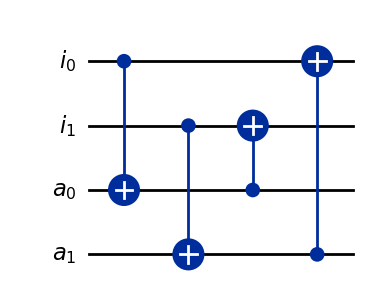

In [6]:
circ = circ_func()

circ.draw('mpl')

Adding Nodes for Circuit: 100%|██████████| 4/4 [00:00<00:00, 27413.75it/s]


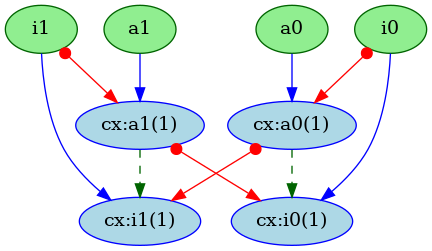

In [7]:
ancillae = get_qubits_of_circuit(circ, 2, ANCILLA)
cg = get_computation_graph(circ, ancillae)

graphviz_draw(cg, node_attr_fn=node_attr, edge_attr_fn=edge_attr)

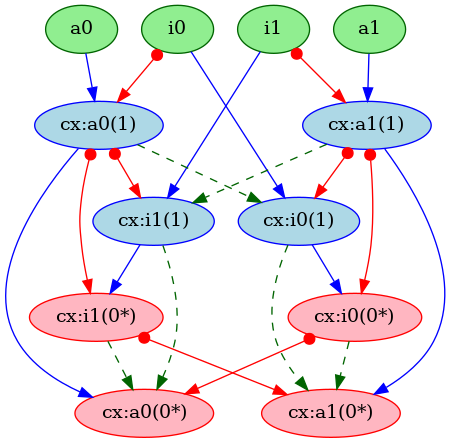

In [8]:
bennetts_ucg = uncomp_all_operations_using_bennetts_in_circuitgraph(cg)
graphviz_draw(bennetts_ucg, node_attr_fn=node_attr, edge_attr_fn=edge_attr)

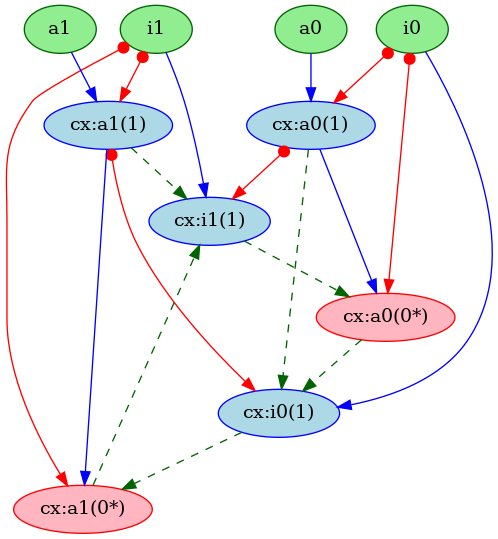

In [9]:
cyclic_ucg, has_cycles = add_uncomputation(cg, ancillae, allow_cycle=True)
graphviz_draw(cyclic_ucg, node_attr_fn=node_attr, edge_attr_fn=edge_attr)

In [10]:
from helperfunctions.graphhelper import CGNode, get_simple_labels
from helperfunctions.reversecircuitgraph import add_uncomp_input_node
from helperfunctions.uncompfunctions import get_comp_node_index

# def get_extra_nodes(node_list_main:List[CGNode], node_list_extra:List[CGNode]):
#     pass
    
# def add_input_uncomp_nodes(uncomp_node:CGNode, circuit_graph:rustworkx.PyDiGraph):
#     uncomp_circuit_graph = copy.deepcopy(circuit_graph)
#     input_init_node = [node for node in uncomp_circuit_graph.nodes() if node.node_type == INIT and node.qubit_type is INPUT and node.label == uncomp_node.label][0]

#     # input_qubits = [node.label for node in input_init_nodes]
#     # input_target_dict = {q:[] for q in input_qubits}
    
#     input_nodes = []

#     try:
#         target_node = uncomp_circuit_graph.find_adjacent_node_by_edge(input_init_node.get_index(), lambda x: x == TARGET)
#     except rustworkx.NoSuitableNeighbors:
#         target_node = None

#     while target_node is not None:
#         input_nodes.append(target_node)
#         try:
#             target_node = uncomp_circuit_graph.find_adjacent_node_by_edge(target_node.get_index(), lambda x: x == TARGET)
#         except rustworkx.NoSuitableNeighbors:
#             target_node = None

#     print(input_nodes)


    

def add_and_reorder_circuit_gates(reduced_circuit_graph:rustworkx.PyDiGraph, cyclic_circuit_graph:rustworkx.PyDiGraph):
    '''
    Try for CG' --> CG''
    Add nodes to cyclic CG until acyclicity is achieved. 
    '''

    reduced_input_uncomp_nodes_sorted = list(filter(
        lambda node: node.node_type == UNCOMP and node.qubit_type == INPUT,
        [reduced_circuit_graph.get_node_data(i) for i in rustworkx.topological_sort(reduced_circuit_graph)]
    ))
    cyclic_cg_copy = copy.deepcopy(cyclic_circuit_graph)
    cyclic_nodes = cyclic_circuit_graph.nodes()
    unique_nodes = [node for node in reduced_input_uncomp_nodes_sorted if node not in cyclic_nodes]
    
    print(get_simple_labels(reduced_input_uncomp_nodes_sorted))
    print(get_simple_labels(cyclic_nodes))
    print(get_simple_labels(unique_nodes))
    # [add_input_uncomp_nodes(node, cyclic_circuit_graph) for node in reduced_input_uncomp_nodes_sorted]
    # while rustworkx.digraph_find_cycle(cyclic_cg_copy):
    for node in reduced_input_uncomp_nodes_sorted:
        if rustworkx.digraph_find_cycle(cyclic_cg_copy):
            print(f'Adding Uncomp Node {node.simple_graph_label()}')
            comp_node_index = get_comp_node_index(reduced_circuit_graph, node.index, plus_nodenum=1)

            cyclic_cg_copy = add_uncomp_input_node(comp_node_index, cyclic_cg_copy)
        else:
            break


    return cyclic_cg_copy  

In [11]:
new_reduced_ucg = add_and_reorder_circuit_gates(bennetts_ucg, cyclic_ucg)

['cx:i0(0*)', 'cx:i1(0*)']
['i0', 'i1', 'a0', 'a1', 'cx:a0(1)', 'cx:a1(1)', 'cx:i1(1)', 'cx:i0(1)', 'cx:a0(0*)', 'cx:a1(0*)']
['cx:i0(0*)', 'cx:i1(0*)']
Adding Uncomp Node cx:i0(0*)
Now uncomputing 7:cx:i0(1)
Cycles from CG removed when added uncomp for cx:i0(1)!


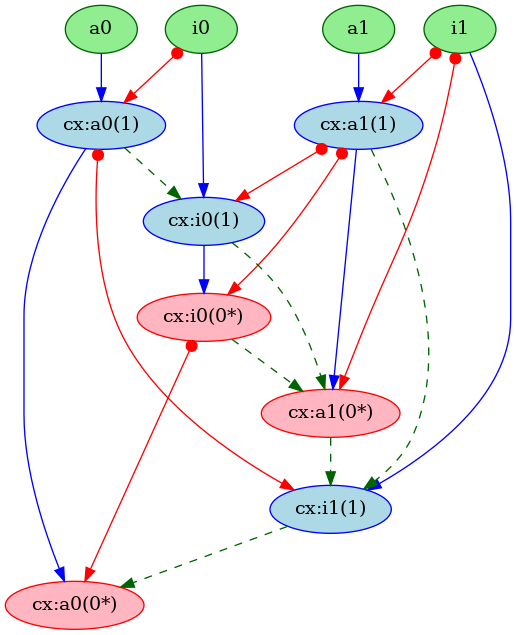

In [12]:
graphviz_draw(new_reduced_ucg, node_attr_fn=node_attr, edge_attr_fn=edge_attr)

Building uncomp circuit from circuit graph: 100%|██████████| 11/11 [00:00<00:00, 66672.46it/s]


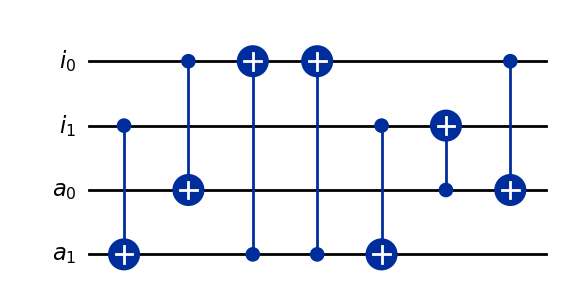

In [13]:
new_reduced_ucirc = get_uncomp_circuit(new_reduced_ucg)

new_reduced_ucirc.draw('mpl')

In [14]:
new_bennetts_ucg = remove_and_reorder_circuit_gates_simple(bennetts_ucg)

Controlled by the node cx:i0(0*) : ['cx:a0(0*)']
Controlled by the node cx:i0(0*) : ['cx:a0(0*)']
Controlled by the node cx:i1(0*) : ['cx:a1(0*)']


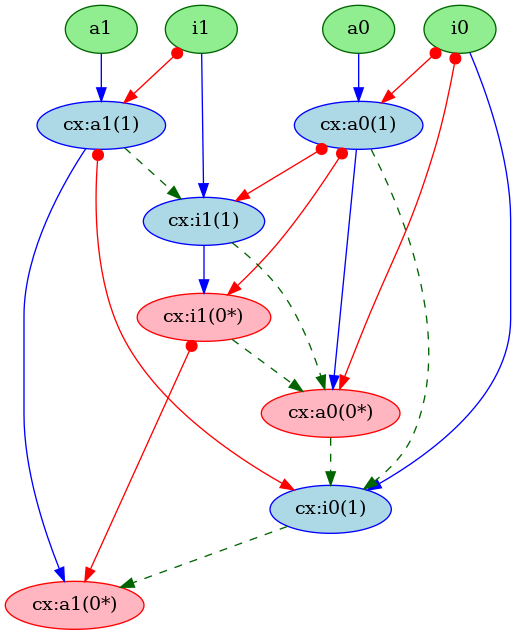

In [15]:
graphviz_draw(new_bennetts_ucg, node_attr_fn=node_attr, edge_attr_fn=edge_attr)

Building uncomp circuit from circuit graph: 100%|██████████| 11/11 [00:00<00:00, 62179.71it/s]


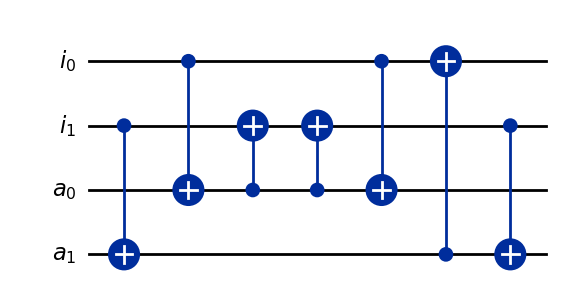

In [16]:
new_bennets_ucirc = get_uncomp_circuit(new_bennetts_ucg)

new_bennets_ucirc.draw('mpl')